importation des libs et chargement des datas

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px  # Interface haut niveau pour graphiques simples
import plotly.graph_objects as go  # Interface bas niveau pour contrôle précis
import seaborn as sns
from plotly.subplots import make_subplots  # Création de grilles de graphiques

#Affichage complet des colonnes et des lignes (pas de retour a la ligne)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)

#Import du fichier csv customer
url = "./../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url,sep=",")

# Affichage des dimension du jeu de données
print(f"Le jeu de données a {df.shape[0]} lignes et {df.shape[1]} colonnes")

# Affichez les 5 premières lignes
print(df.head())




Le jeu de données a 7043 lignes et 21 colonnes
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes    

Affichez les types de données de chaque colonne

Nombre pour chaque variable

In [57]:
# Affichez les types de données de chaque colonne
print(df.dtypes)
print(" " * 50)
print("-" * 50)
print(" " * 50)
#Nombre de manquants pour chaque colonnes

# remplace les chaînes vides par NaN dans les colonnes de type objet ou string
cols_str = df.select_dtypes(include=["object", "string"]).columns
df[cols_str] = df[cols_str].replace(r"^\s*$", np.nan, regex=True)


if (df.isna().sum() == 0).all():
    print("Il ne manque aucune valeur.")
else:
    print("Il y a des valeurs manquantes.")
    print(f"{df.isna().sum()}")  

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
                                                  
--------------------------------------------------
                                                  
Il y a des valeurs manquantes.
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineS

Il y a des manquant sur TotalCharges
Passage du types str au type float. (elle est en str mais il n'y a que des floats, elle doit etre en Float)


In [58]:
# Convertir en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Vérifier
print("NaN TotalCharges:", df["TotalCharges"].isna().sum())  # devrait afficher 11
print(df["TotalCharges"].dtype)  # float64 attendu

#affichage des lignes avec des valeurs manquantes
print(df[df["TotalCharges"].isna()])

NaN TotalCharges: 11
float64
      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies  Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI  Female              0     Yes        Yes       0           No  No phone service             DSL                  Yes                   No                  Yes                  Yes                  Yes                   No  Two year              Yes  Bank transfer (automatic)           52.55           NaN    No
753   3115-CZMZD    Male              0      No        Yes       0          Yes                No              No  No internet service  No internet service  No internet service  No internet service  No internet service  No internet service  Two year               No               Mailed check           20.25  

Recherche correlation avec les autre colonnes numerique

TotalCharges      1.000000
tenure            0.825880
MonthlyCharges    0.651065
SeniorCitizen     0.102411
Name: TotalCharges, dtype: float64


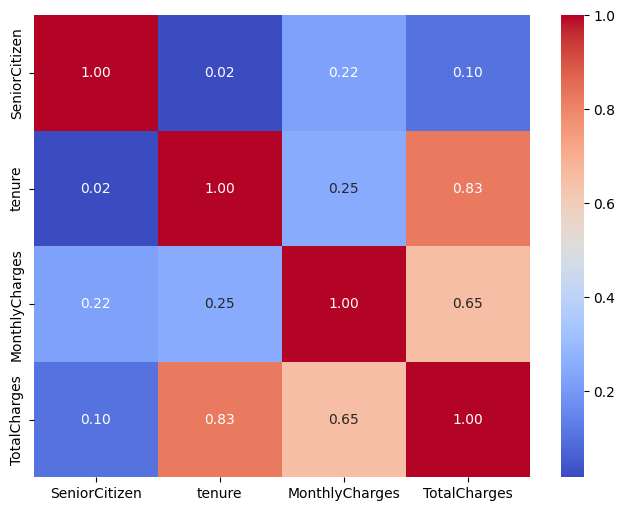

In [59]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix["TotalCharges"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

On voit une correlation avec tenure (0.83) et MonthlyCharge (0.65. moins mais quand meme)
si on regarde les c'est 2 colonnes on peut voir que tenure x MonthlyCharge et tres proche de totalCharges 
=> remplir les manquants de TotalCharges par tenure x MonthlyCharge. Dans notre cas tenure = 0 pour les manquant donc c'est normale de ne rien avoir
 je pourrais directement mettre 0 dans TotalCharges mais pour le fun je fais le calcul

In [60]:
#remplace les valeurs manquantes par tenure* MonthlyCharges
mask = df["TotalCharges"].isna()
df.loc[mask, "TotalCharges"] = df.loc[mask, "tenure"] * df.loc[mask, "MonthlyCharges"]

print(df.loc[mask].to_string())

# verification des manquants
if (df.isna().sum() == 0).all():
    print("Il ne manque aucune valeur maintenant.")
else:
    print("Il y a ENCORE des valeurs manquantes.")
    print(f"{df.isna().sum()}")  
    

      customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies  Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI  Female              0     Yes        Yes       0           No  No phone service             DSL                  Yes                   No                  Yes                  Yes                  Yes                   No  Two year              Yes  Bank transfer (automatic)           52.55           0.0    No
753   3115-CZMZD    Male              0      No        Yes       0          Yes                No              No  No internet service  No internet service  No internet service  No internet service  No internet service  No internet service  Two year               No               Mailed check           20.25           0.0    No
936   5709

Recherche de doublon

In [23]:
#Recherhce de doublon
print(f"Il y a {df.duplicated().sum()} doublons dans le jeu de données.")
if df.duplicated().sum() > 0:
    print("Voici les lignes en double :")
    print(df[df.duplicated()])

Il y a 0 doublons dans le jeu de données.


Recherche des valeur aberrantes (outlier)
1 Visualisation (boxpplot) sur les valeurs numerique
2 tableau recaptulatif des valeures yes ou no pour les colonnes "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"
        idem pour MultipleLines mais il y a 3 valeurs possible (Yes/No/No phone service)
    si besoin 2 approche
        1 Stat
        2 Machine Learning

In [24]:

# Creaton DataFrame pour ne garder que les valeur numerique pour le boxplot (SeniorCitizen, tenure, MonthlyCharges et un global pour les trois)
df_numeric = df.select_dtypes(include=[np.number])
df_SeniorCitizen = df_numeric["SeniorCitizen"]
df_tenure = df_numeric["tenure"]
df_MonthlyCharges = df_numeric["MonthlyCharges"]
#Creation d'une figure 1 ligne 3 colonnes
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Distribution DSeniorCitizen', 'Distribution Dtenure',' Distribution MonthlyCharges')
)

fig.add_trace(go.Box(y=df_SeniorCitizen, name="SeniorCitizen"), row=1, col=1)
fig.update_xaxes(title_text="SeniorCitizen", row=1, col=1)
fig.update_yaxes(title_text="ancienneté 1/0", row=1, col=1)

fig.add_trace(go.Box(y=df_tenure, name="tenure"), row=1, col=2)
fig.update_xaxes(title_text="tenure", row=1, col=2)
fig.update_yaxes(title_text="Ancienneté client (mois)", row=1, col=2)

fig.add_trace(go.Box(y=df_MonthlyCharges, name="MonthlyCharges"), row=1, col=3)
fig.update_xaxes(title_text="MonthlyCharges", row=1, col=3)
fig.update_yaxes(title_text="Facturation mensuelle", row=1, col=3)


# Affichage du graphique
fig.show()

In [25]:
#Recherche valeur autre que Yes No pour "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"

cols_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn","MultipleLines"]
valeurs_autorisees = ["Yes", "No","No phone service"]

for col in cols_yes_no:
    s = df[col]
    #selection des valeurs non NaN qui ne sont pas dans les valeurs autorisées
    if col == "MultipleLines":
        invalides = s[s.notna() & ~s.astype(str).str.strip().isin(valeurs_autorisees)]
    else:
        #pour les colonnes autre que MultipleLines, les valeurs autorisées sont uniquement "Yes" et "No"
        invalides = s[s.notna() & ~s.astype(str).str.strip().isin(valeurs_autorisees[:2])]
        

    
    if invalides.empty:
        print(f"{col}: OK (NaN={s.isna().sum()})")
    else:
        print(f"{col}: INVALIDES -> {invalides.unique()} (NaN={s.isna().sum()})")



Partner: OK (NaN=0)
Dependents: OK (NaN=0)
PhoneService: OK (NaN=0)
PaperlessBilling: OK (NaN=0)
Churn: OK (NaN=0)
MultipleLines: OK (NaN=0)
